In [1]:
import os
os.chdir(r'C:\Users\Klara\retail-intelligence')
print(os.getcwd())

C:\Users\Klara\retail-intelligence


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

demand = pd.read_csv('data/processed/weekly_demand.csv')
demand['Week'] = pd.to_datetime(demand['Week'])

print("Shape:", demand.shape)
print("Columns:", demand.columns.tolist())
print("Products:", demand['StockCode'].nunique())
print("Weeks:", demand['Week'].nunique())
print("\nDate range:", demand['Week'].min(), "to", demand['Week'].max())

# Pick the single best product for Day 1
# Best = most consistent sales history (fewest zero weeks)
product_completeness = (
    demand.groupby('StockCode')['TotalQuantity']
    .apply(lambda x: (x > 0).mean())
    .sort_values(ascending=False)
)

print("\nTop 5 products by data completeness (% weeks with sales):")
print(product_completeness.head())

best_product = product_completeness.index[0]
print(f"\nSelected product for Day 1: {best_product}")

Shape: (1080, 7)
Columns: ['StockCode', 'Week', 'TotalQuantity', 'TotalRevenue', 'NumOrders', 'NumCustomers', 'Description']
Products: 20
Weeks: 54

Date range: 2010-11-29 00:00:00 to 2011-12-05 00:00:00

Top 5 products by data completeness (% weeks with sales):
StockCode
21915    0.981481
21212    0.981481
22178    0.981481
21977    0.981481
84946    0.981481
Name: TotalQuantity, dtype: float64

Selected product for Day 1: 21915


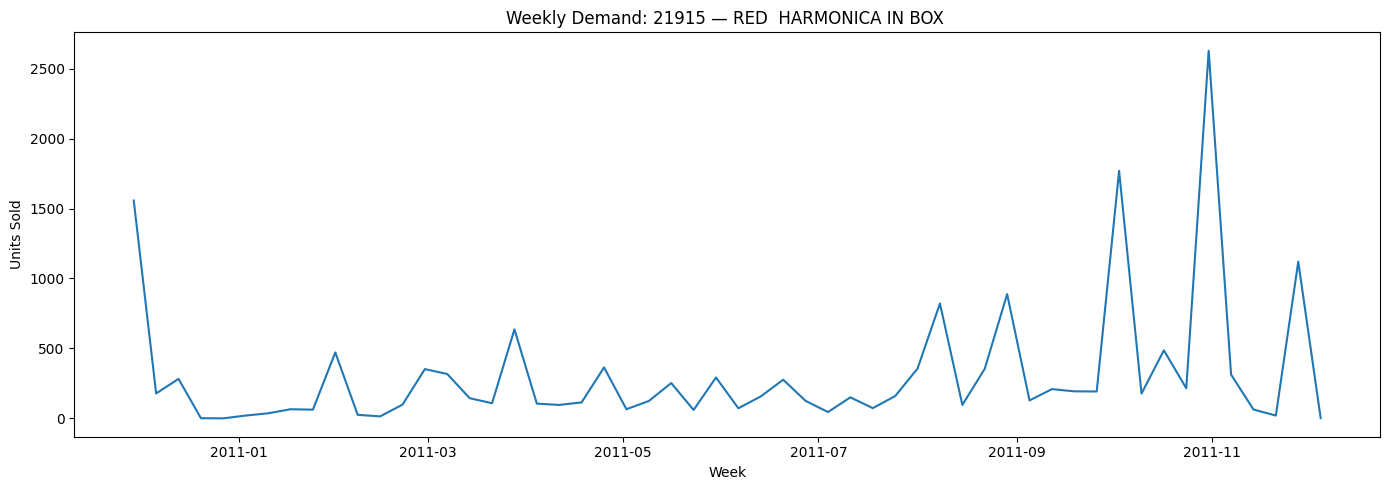


Product stats:
count      54.000000
mean      313.425926
std       480.031115
min         0.000000
25%        66.750000
50%       153.500000
75%       316.000000
max      2628.000000
Name: TotalQuantity, dtype: float64


In [3]:
# Plot
product_data = demand[demand['StockCode'] == best_product].copy()
product_name = product_data['Description'].iloc[0]

plt.figure(figsize=(14, 5))
plt.plot(product_data['Week'], product_data['TotalQuantity'])
plt.title(f"Weekly Demand: {best_product} — {product_name[:50]}")
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.savefig('notebooks/best_product_demand.png')
plt.show()

print(f"\nProduct stats:")
print(product_data['TotalQuantity'].describe())

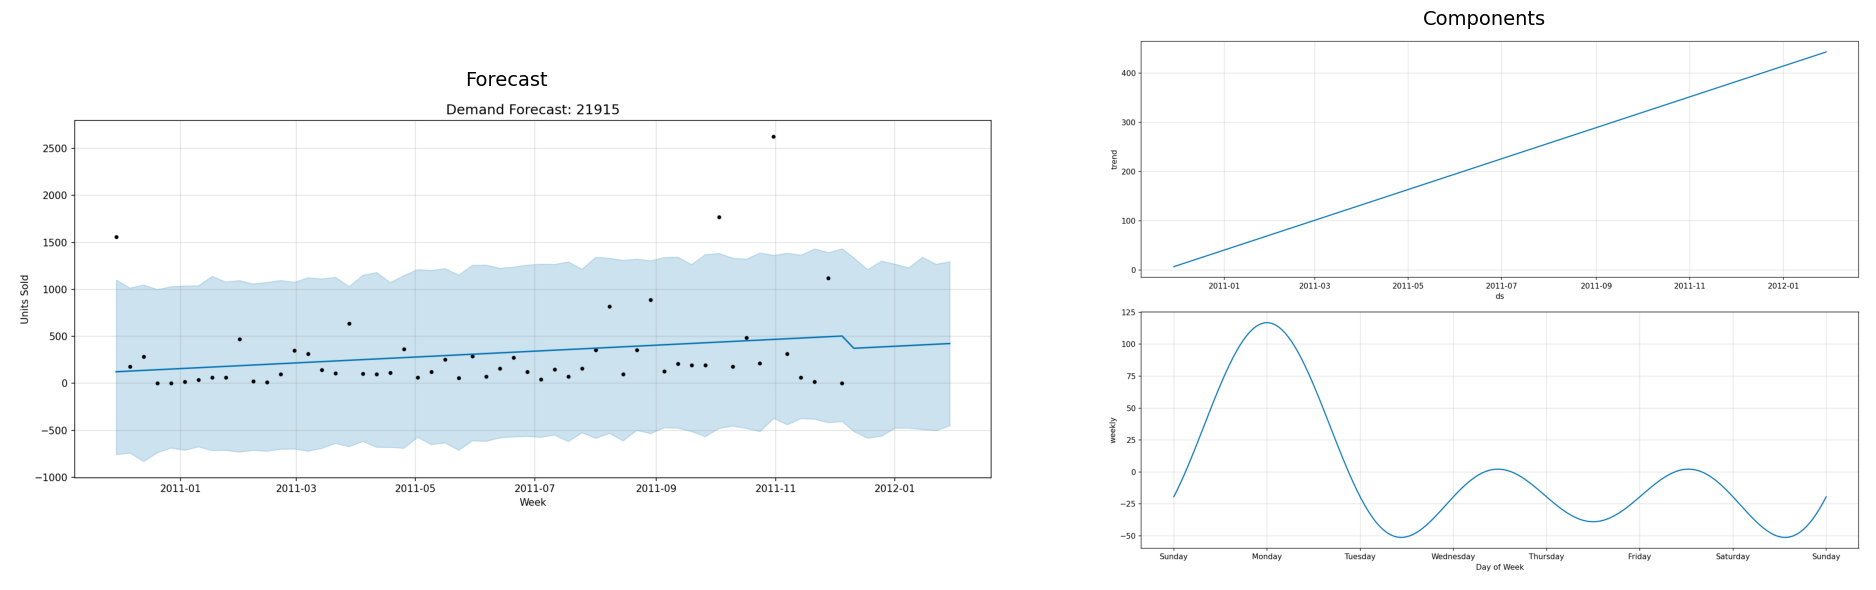

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

product_code = "21915"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

forecast_img = mpimg.imread(f'notebooks/demand_plots/{product_code}_forecast.png')
components_img = mpimg.imread(f'notebooks/demand_plots/{product_code}_components.png')

axes[0].imshow(forecast_img)
axes[0].axis('off')
axes[0].set_title('Forecast', fontsize=14)

axes[1].imshow(components_img)
axes[1].axis('off')
axes[1].set_title('Components', fontsize=14)

plt.tight_layout()
plt.show()

## Day 1 — Notes & Observations


**Data exploration cell** — loaded `weekly_demand.csv` (1080 rows, 20 products, 54 weeks, Nov 2010–Dec 2011). Calculated data completeness per product (% of weeks with nonzero sales) to pick the best candidate for a first single-product test. Top 5 products tied at 98.1% completeness (53/54 weeks with sales); selected `21915` ("RED HARMONICA IN BOX") as it came first in the tie.

**Plot cell** — plotted weekly demand for `21915`. Mean = 313.4 units, std = 480 (std > mean — high variance), median = 153.5, max = 2628. Demand is spiky with a clear ramp-up Sept–Nov, consistent with pre-Christmas gift-item ordering. This is a noisier, more realistic first test case than a smooth product would have been.

**`prophet_model.py` — first run** — fit Prophet with `yearly_seasonality=True`and UK holidays enabled. Produced deeply negative 8-week forecasts (`yhat` ranging from -848 to -1938 units) — not plausible for a product whose real demand never goes below 0.

**`prophet_model.py` — components plot (first run)** — diagnosed the bug: 
- `trend` sloped continuously downward with no bound (0 → -800)
- `yearly` swung from +1000 (Nov) to -1100 (Jan) — an implausibly large range given actual demand only spans 0–2628
- `holidays` showed a +550 Christmas effect

**`prophet_model.py` — second run (after fix)** — disabled `yearly_seasonality` and removed `add_country_holidays('UK')`. Forecast became plausible: `yhat` ranged 374–424, close to the historical mean (313.4). `yhat_lower` still dips negative (expected — will be clipped to 0 in Day 2's pipeline, since demand can't be negative).

**Components plot (after fix)** — only `trend` and `weekly` remain. Trend is a smooth, gentle upward slope (0 → ~440). Weekly seasonality peaks Monday (+115), troughs Tue/Fri (~-50) — a legitimate, well-supported pattern since it repeats 54 times across the dataset.

---

### Why the first run broke, and why the fix is principled (not just "delete until it works")

Prophet's forecast is additive: `yhat = trend + weekly + yearly + holidays + noise`. Each component is estimated independently, then summed — so if multiple components are wrong in the same direction at the same point in time, their errors compound rather than cancel.

**Yearly seasonality** is fit as a Fourier curve across the calendar year. With only ~54 weeks (one pass through the calendar), Prophet has no way to tell a real, recurring annual pattern apart from "whatever this one year happened to look like." It effectively memorized the shape of my one year — including the November spike and the drop after it — and called that the "yearly pattern."

**UK holidays** are estimated per calendar date from however many times that date appears in training data. With one year of history, almost every holiday (Christmas, Boxing Day, New Year) occurs exactly once — so its "effect" is really just one data point being treated as a reusable signal, not an estimated pattern.

**Why the forecast broke specifically in Dec–Jan:** the 8-week forecast window landed exactly on the same calendar dates as the worst part of the yearly curve (the -1100 trough around Jan 1) and overlapped with the single-occurrence New Year holiday estimate. Trend, yearly, and holidays all pointed negative at that same calendar location and summed together, producing forecasts around -1900.

**The fix:** disable `yearly_seasonality` and UK holidays. This isn't hiding a limitation — it reflects what Prophet's own documentation recommends: yearly seasonality and holiday effects need multiple years of history to be identifiable (i.e., more than one example to average over, so the model can separate signal from a one-off event). With ~1 year, neither condition is met.

What's left — trend and weekly — are both legitimately supported by the data: trend uses the full 54-week span, and weekly seasonality repeats 54 separate times, giving the model real replication to average across. That's the difference between a component that's *estimated* and one that's *memorized*.

**Takeaway for later weeks:** since all 20 products share this same ~54-week date range, this same yearly/holiday instability will affect the full batch tomorrow — so `yearly_seasonality=False` and no UK holidays should be the default config going into Day 2, not a one-off fix for this single product.

### Correction (added during Day 2)

The Day 1 reasoning above claimed weekly seasonality was trustworthy because it "repeats 54 times across the dataset." This was wrong. Checking 
`demand['Week'].dt.day_name().unique()` on Day 2 showed every training date falls on the same weekday (Monday) — meaning Prophet had zero real variation across days of the week to learn from, despite having 54 weekly totals. It fit a full day-of-week curve anyway, and since forecast dates defaulted to a different weekday (Sunday via `freq='W'`), forecasts landed on an unconstrained part of that curve — causing implausible crashes (e.g. product 84077: historical mean ~910, forecast ~100). 

Fixed on Day 2 by also disabling `weekly_seasonality` and switching `make_future_dataframe` to `freq='W-MON'` so forecast dates match the training cadence. See Day 2 notes in `13_multi_product_forecasts.ipynb` for the full diagnosis. Final model config: trend only, no yearly/weekly/holiday components — the only component genuinely supported by weekly-aggregated, single-weekday data.